In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from src.model_pipeline import ModelPipeline

In [2]:
df_final = pd.read_parquet(
    "data/feature_engineering/debit/v2/df_union_debit_final.parquet"
)
df_final = df_final.set_index("Transaction Serial No", drop=True)

# Box-Plot Numerical Importance Features

In [10]:
split_date = "2025-05-01"

In [11]:
# setup pipeline
pipeline = ModelPipeline(model_type="random_forest", random_state=42)

Initializing ModelPipeline with model type: random_forest
Retrieving model instance for type: random_forest


In [12]:
df_splits = pipeline.split_data_by_date(
    df=df_final, date_column="Transaction Datetime", split_date=split_date
)

Splitting data by date (pre-preprocessing)...
Train samples: 647760, Test samples: 66974
Data splitting complete.


In [13]:
# prepare data
target_col = "Confirmed"
X, y = pipeline.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Debit_No", "Transaction Datetime"],
    is_apply_one_hot=False,
    is_apply_log=False,
    is_impute_median=False,
    is_training=True,
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
  Mapping Y/N to 1/0 in column: BDIStaff
  Mapping Y/N to 1/0 in column: IsBlacklistAccount
  Mapping Y/N to 1/0 in column: IsHighRiskCountry
  Mapping Y/N to 1/0 in column: IsBlacklistMerchant
  Mapping Y/N to 1/0 in column: IsWatchListMerchant
  Mapping Y/N to 1/0 in column: IsBlacklistCardNo
  Mapping Y/N to 1/0 in column: IsWhiteListMerchant
  Mapping Y/N to 1/0 in column: IsBDIEmail
  Mapping Y/N to 1/0 in column: IsWhiteListCardNo
  Mapping Y/N to 1/0 in column: IsWhiteListAccountNo
  Mapping Y/N to 1/0 in column: IsWatchListAccountNo
  Mapping Y/N to 1/0 in column: IsVAAccount
  Mapping Y/N to 1/0 in column: IsExcludeTeminalId
  Mapping Y/N to 1/0 in column: isBDICard
  Mapping Y/N to 1/0 in column: IsTopUp
  Mapping Y/N to 1/0 in column: IsBillPayment
  Mapping Y/N to 1/0 in column: IsPaymentToVA
  Mapping Y/N to 1/0 in column: IsFTTrx
Core numeric and boolean preprocessing complete.
Fitting

In [14]:
X_oos, y_oos = pipeline.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Debit_No", "Transaction Datetime"],
    is_apply_one_hot=False,
    is_apply_log=False,
    is_impute_median=False,
    is_training=False,
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
  Mapping Y/N to 1/0 in column: BDIStaff
  Mapping Y/N to 1/0 in column: IsBlacklistAccount
  Mapping Y/N to 1/0 in column: IsHighRiskCountry
  Mapping Y/N to 1/0 in column: IsBlacklistMerchant
  Mapping Y/N to 1/0 in column: IsWatchListMerchant
  Mapping Y/N to 1/0 in column: IsBlacklistCardNo
  Mapping Y/N to 1/0 in column: IsWhiteListMerchant
  Mapping Y/N to 1/0 in column: IsBDIEmail
  Mapping Y/N to 1/0 in column: IsWhiteListCardNo
  Mapping Y/N to 1/0 in column: IsWhiteListAccountNo
  Mapping Y/N to 1/0 in column: IsWatchListAccountNo
  Mapping Y/N to 1/0 in column: IsVAAccount
  Mapping Y/N to 1/0 in column: IsExcludeTeminalId
  Mapping Y/N to 1/0 in column: isBDICard
  Mapping Y/N to 1/0 in column: IsTopUp
  Mapping Y/N to 1/0 in column: IsBillPayment
  Mapping Y/N to 1/0 in column: IsPaymentToVA
  Mapping Y/N to 1/0 in column: IsFTTrx
Core numeric and boolean preprocessing complete.
Transf

In [15]:
df_train = df_splits["df_train"].drop("Confirmed", axis=1).copy()
df_train["Confirmed"] = df_splits["df_train"]["Confirmed"]

## Time Difference (in Minutes)

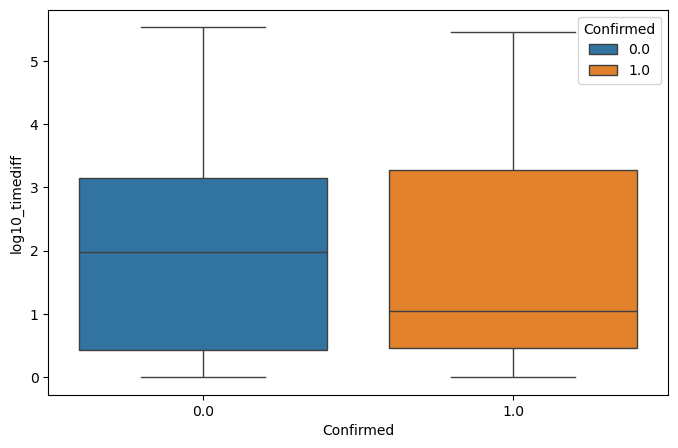

In [7]:
df_train["log10_timediff"] = np.log10(df_train["time_diff"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="log10_timediff", hue="Confirmed", data=df_train)
plt.show()

## Transaction Amount

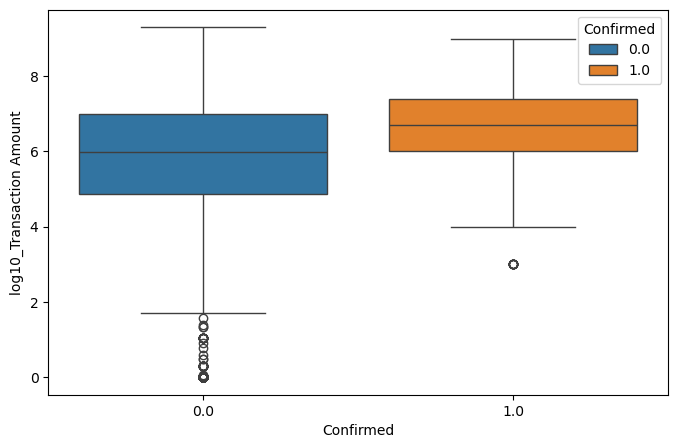

In [9]:
df_train["log10_Transaction Amount"] = np.log10(df_train["Transaction Amount"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="log10_Transaction Amount", hue="Confirmed", data=df_train)
plt.show()

## Transaction Count Last 15m, 1H

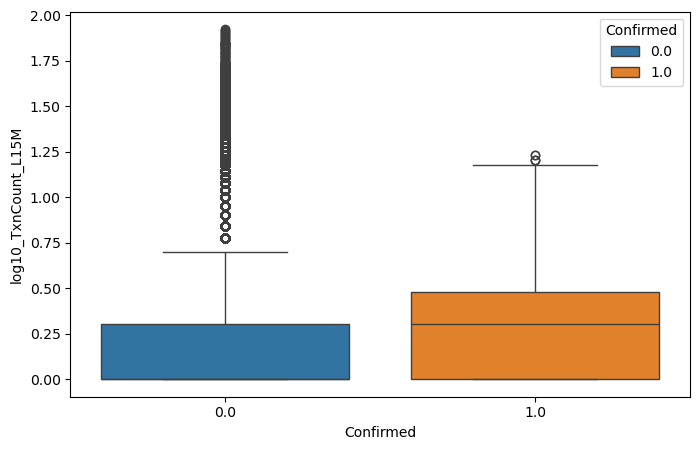

In [38]:
df_train["log10_TxnCount_L15M"] = np.log10(df_train["TxnCount_L15M"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="log10_TxnCount_L15M", hue="Confirmed", data=df_train)
plt.show()

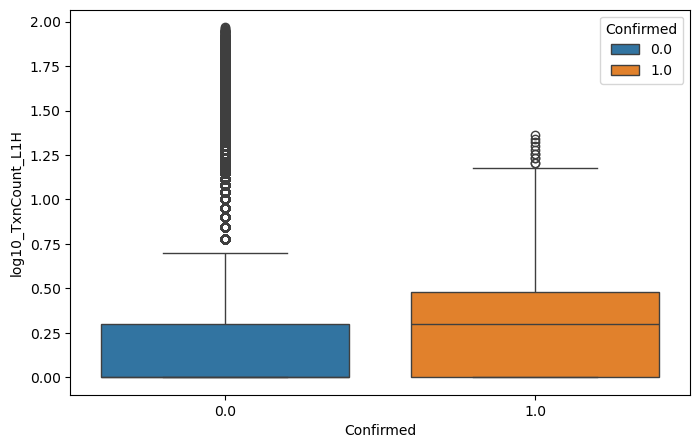

In [36]:
df_train["log10_TxnCount_L1H"] = np.log10(df_train["TxnCount_L1H"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="log10_TxnCount_L1H", hue="Confirmed", data=df_train)
plt.show()

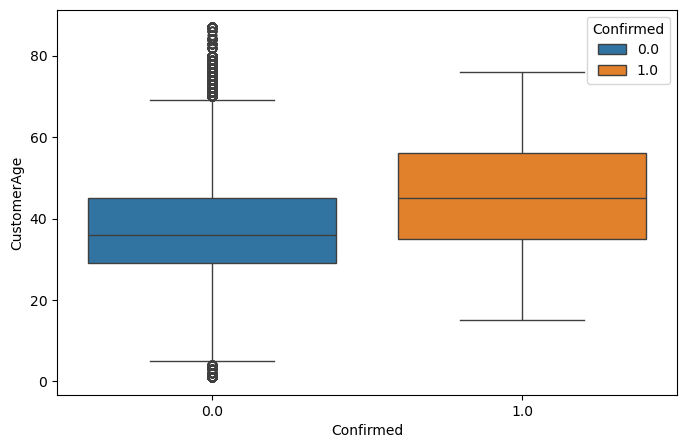

In [12]:
# df_train["log10_MCC_Category_FE"] = np.log10(df_train["MCC Category_FE"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="CustomerAge", hue="Confirmed", data=df_train)
plt.show()

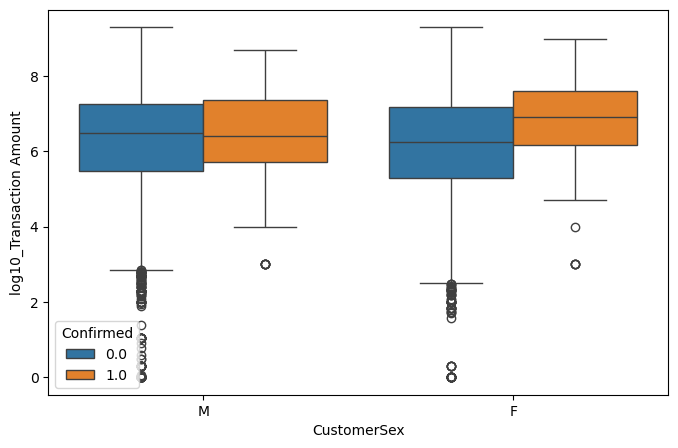

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="CustomerSex", y="log10_Transaction Amount", hue="Confirmed", data=df_train
)
plt.show()

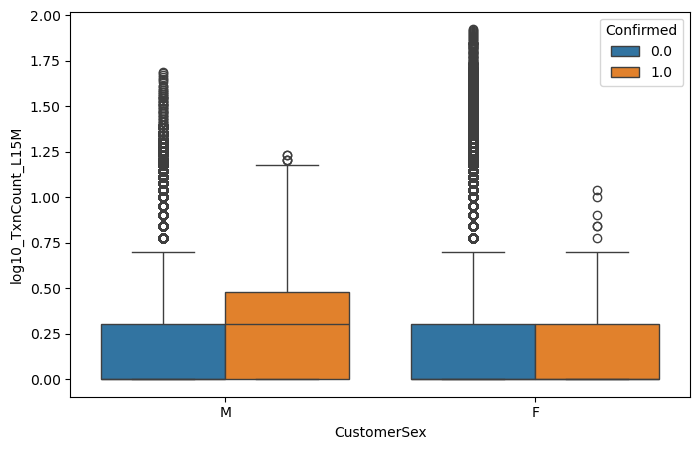

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="CustomerSex", y="log10_TxnCount_L15M", hue="Confirmed", data=df_train)
plt.show()

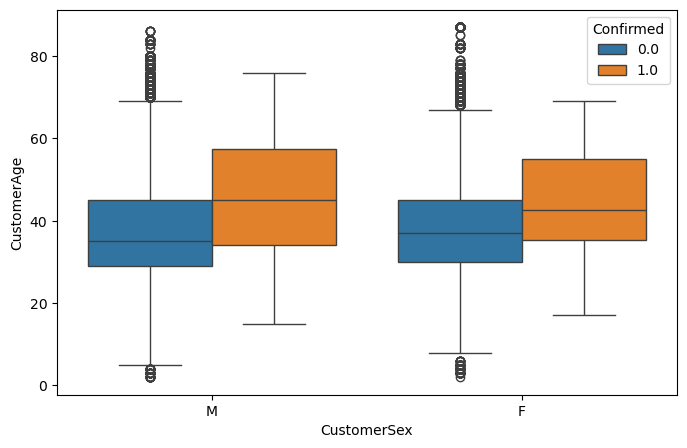

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="CustomerSex", y="CustomerAge", hue="Confirmed", data=df_train)
plt.show()

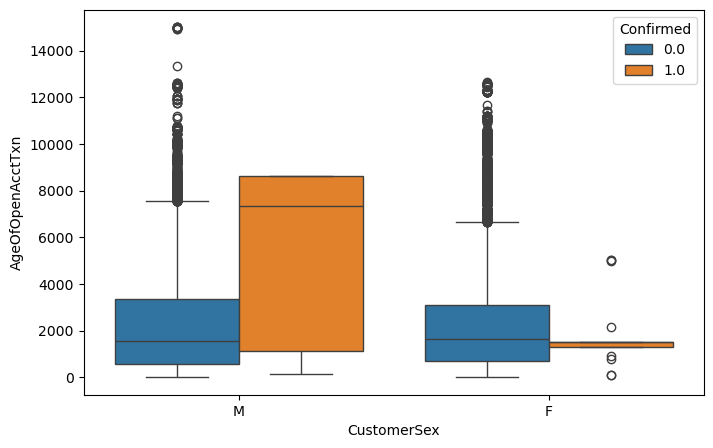

In [14]:
# df_train["log10_AgeOfOpenAcctTxn"] = np.log10(df_train["AgeOfOpenAcctTxn"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="CustomerSex", y="AgeOfOpenAcctTxn", hue="Confirmed", data=df_train)
plt.show()

# Gini Feature Importance, PSI, and IV

## Gini Feature Importance

In [8]:
importance_df = pd.read_csv(
    "data/result/debit_model_feature_importance_rf_20250617.csv"
)

In [9]:
feat_importance_list = importance_df[
    importance_df["importance"] > 1e-05
].feature.tolist()

In [10]:
len(feat_importance_list)

246

## PSI

In [3]:
from src.feature_stability import (
    calculate_iv_for_all_features,
    calculate_psi_for_all_features,
)

In [17]:
df_splits["df_train"] = df_splits["df_train"].drop("Transaction Datetime", axis=1)
df_splits["df_test"] = df_splits["df_test"].drop("Transaction Datetime", axis=1)

In [18]:
numerical_cols = X.select_dtypes(include=["float32", "float64"])

psi_df = calculate_psi_for_all_features(
    train_df=X, test_df=X_oos, features=numerical_cols, buckets=10
)

Calculate PSI Progress...:   0%|          | 241/647760 [00:16<12:18:53, 14.61it/s]


In [4]:
# psi_df.to_csv("data/result/debit_model_feature_PSI_20250617.csv", index=False)
psi_df = pd.read_csv("data/result/debit_model_feature_PSI_20250617.csv")

In [5]:
feat_high_psi = psi_df[psi_df["PSI"] > 0.2].Feature.tolist()

In [6]:
len(feat_high_psi)

0

In [11]:
final_feat_yet = [col for col in feat_importance_list if col not in feat_high_psi]

In [12]:
len(final_feat_yet)

246

## Information Value (IV)

In [20]:
numerical_cols = X.select_dtypes(include=["float32", "float64"])

iv_df = calculate_iv_for_all_features(
    df=X.join(y), features=numerical_cols, target="Confirmed", bins=10
)

Calculate IV Progress...:   0%|          | 0/647760 [00:00<?, ?it/s]C:\Users\Administrator\BDI-predator\ml-fraud\src\feature_stability.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")[target].agg(["count", "sum"])
Calculate IV Progress...:   0%|          | 1/647760 [00:00<114:25:36,  1.57it/s]C:\Users\Administrator\BDI-predator\ml-fraud\src\feature_stability.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")[target].agg(["count", "sum"])
Calculate IV Progress...:   0%|          | 2/647760 [00:01<109:45:45,  1.64it/s]C:\Users\Administrator\BDI-preda

In [13]:
# pd.set_option("display.max_rows", None)
# iv_df.to_csv("data/result/debit_model_feature_IV_20250617.csv", index=False)
iv_df = pd.read_csv("data/result/debit_model_feature_IV_20250617.csv")

In [20]:
low_iv_feats = iv_df[iv_df["IV"] < 0.1].Feature.tolist()

In [25]:
len(low_iv_feats)

54

In [23]:
final_feats = [col for col in final_feat_yet if col not in low_iv_feats]

In [24]:
# iv_df[iv_df['Feature'].isin(low_iv_feats)]
low_iv_feats

['TotalTrxAmountVA2',
 'Sum_Amt_to_MCC_cat_L90D',
 'Max_Amt_to_MCC_cat_L1H',
 'Max_Amt_to_MCC_cat_L1D',
 'Avg_Amt_to_cardAcceptor_cat_L14D',
 'TxnCount_L15M',
 'TxnCount_L1H',
 'Sum_Amt_to_MCC_cat_L7D',
 'TxnCount_to_cardAcceptor_cat_L15M',
 'Sum_Amt_to_MCC_cat_L1D',
 'NumOfTrxL15Min',
 'Avg_Amt_to_cardAcceptor_cat_L30D',
 'CntUnique_MCC_by_CardNo_L90D',
 'CntUnique_MCC_by_CardNo_L1H',
 'CntUnique_MCC_by_CardNo_L1D',
 'Avg_Amt_L14D',
 'Max_Amt_to_MCC_cat_L15M',
 'Avg_Amt_to_MCC_cat_L15M',
 'AgeOfActiveCardTxn',
 'CntUnique_MCC_by_CardNo_L7D',
 'NumOfTrxL1D',
 'TxnCount_to_cardAcceptor_cat_L1H',
 'Avg_Amt_L7D',
 'TimeDiffCurrPrev',
 'CntUnique_MCC_by_CardNo_L14D',
 'Max_Amt_to_MCC_cat_L7D',
 'TxnCount_to_MCC_catcode_L1D',
 'TxnCount_to_MCC_cat_L1D',
 'Max_Amt_to_MCC_cat_L14D',
 'CntUnique_MCC_by_CardNo_L30D',
 'Max_Amt_to_MCC_cat_L90D',
 'isBDICard',
 'TxnCount_to_MCC_catcode_L1H',
 'TxnCount_to_MCC_cat_L1H',
 'Max_Amt_to_MCC_cat_L30D',
 'TxnCount_to_MCC_catcode_L15M',
 'TxnCount_to_MCC

In [26]:
final_feats

['CntUnique_CardNo_by_cardAcceptor_cat_L90D',
 'CntUnique_CardNo_by_cardAcceptor_cat_L14D',
 'CntUnique_CardNo_by_cardAcceptor_cat_L1D',
 'CntUnique_CardNo_by_cardAcceptor_cat_L7D',
 'Sum_Amt_L90D',
 'CntUnique_CardNo_by_cardAcceptor_cat_L30D',
 'Sum_Amt_to_cardAcceptor_cat_L90D',
 'CntUnique_CardNo_by_MCC_L14D',
 'TxnCount_to_cardAcceptor_cat_L30D',
 'Sum_Amt_L30D',
 'Sum_Amt_to_cardAcceptor_cat_L30D',
 'TotalTrxAmount15Mi',
 'Transaction Amount',
 'Sum_Amt_L14D',
 'CntUnique_CardNo_by_MCC_L7D',
 'TxnCount_to_cardAcceptor_cat_L14D',
 'TotalTrxAmount10Mi',
 'CntUnique_CardNo_by_MCC_L30D',
 'CntUnique_CardNo_by_MCC_L1D',
 'TotalTrxAmountL5min',
 'TxnCount_L90D',
 'TxnCount_L30D',
 'CntUnique_CardNo_by_MCC_L90D',
 'TxnCount_L14D',
 'Sum_Amt_to_cardAcceptor_cat_L14D',
 'CountTrxTrf',
 'TotalTrxAmountL1D',
 'TxnCount_L7D',
 'TxnCount_to_cardAcceptor_cat_L90D',
 'TxnCount_to_cardAcceptor_cat_L7D',
 'Balance',
 'Sum_Amt_to_cardAcceptor_cat_L7D',
 'TotalTrxAmountTrf2',
 'TotalTrxAmountTrf',
 

In [24]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression


def remove_correlated_features_target_aware(
    df,
    target,
    features,
    problem_type="classification",
    threshold=0.85,
    method="pearson",
    verbose=True,
):
    """
    Removes highly correlated feature while keeping the most predictive one
    based on correlation to target
    """

    df_numeric = df[features]
    corr_matrix = df_numeric.corr(method=method).abs()
    upper = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_corr = corr_matrix.where(upper)

    # calculate feature importance to target
    if problem_type == "classification":
        feature_scores = pd.Series(
            mutual_info_classif(df_numeric.fillna(0), target), index=df_numeric.columns
        )
    elif problem_type == "regression":
        feature_scores = pd.Series(
            mutual_info_regression(df_numeric.fillna(0), target),
            index=df_numeric.columns,
        )
    else:
        raise ValueError("problem type must be 'classification' or 'regression'")

    removed = set()

    # greedily remove less important features from each highly correlated pair
    for col in upper_corr.columns:
        for row in upper_corr.index:
            if upper_corr.loc[row, col] > threshold:
                if row in removed or col in removed:
                    continue
                score_row = feature_scores[row]
                score_col = feature_scores[col]
                if score_row >= score_col:
                    remove.add(col)
                else:
                    removed.add(row)

    if verbose:
        print(f"Removed columns: {list(removed)}")

    return list(removed)

In [28]:
high_corr_feats = remove_correlated_features_target_aware(
    df=X,
    target=y,
    features=final_feats,
    problem_type="classification",
    threshold=0.85,
)


KeyboardInterrupt



In [ ]:
high_corr_feats